In [1]:
from matplotlib import pyplot as plt
from scipy.interpolate import CubicSpline
import numpy as np
import numba as nb
from UTILS import step_all_particles, InitialCondition, dt, evolve_all_particles
from UTILS import Gradient_Computation_1d, Gradient_Computation_3d, InitialCondition_3d
from scipy.stats import maxwell
import time
import os
os.environ["NUMBA_THREADING_LAYER"] = "workqueue"

In [2]:
!pip install numba

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# Constants class, values are loaded from UTILS.py
from UTILS import mass, dt, bohr_magneton, kB
from UTILS import Temperature, Temperature_transv
from UTILS import Zmin, Zmax, Zmid, zacceptance_min, zacceptance_max
from UTILS import harmonic_degree, harmonic_coefficient

In [4]:
# Override temperatures 
Temperature = 4e-3 # K
Temperature_transv = 4e-3 # K
theta      = 0
tau_mixing = 100
stringa    = ""

In [5]:
class constants:
    def __init__(self, 
                 mass, 
                 dt, 
                 bohr_magneton,
                 kB,
                 Temperature,
                 Temperature_transv,
                 Zmin,
                 Zmax,
                 Zmid,
                 zacceptance_min,
                 zacceptance_max,
                 harmonic_degree,
                 harmonic_coefficient,
                 tau_mixing):
        self.mass = mass
        self.dt = dt
        self.bohr_magneton = bohr_magneton
        self.kB = kB
        self.Temperature = Temperature
        self.Temperature_transv = Temperature_transv
        self.Zmin = Zmin
        self.Zmax = Zmax
        self.Zmid = Zmid
        self.zacceptance_min = zacceptance_min
        self.zacceptance_max = zacceptance_max
        self.harmonic_degree = harmonic_degree
        self.harmonic_coefficient = harmonic_coefficient
        self.tau_mixing = tau_mixing
    mu_eff_over_m = bohr_magneton / mass

CONSTANTS = constants(mass, 
                 dt, 
                 bohr_magneton,
                 kB,
                 Temperature,
                 Temperature_transv,
                 Zmin,
                 Zmax,
                 Zmid,
                 zacceptance_min,
                 zacceptance_max,
                 harmonic_degree,
                 harmonic_coefficient,
                 tau_mixing)

print(CONSTANTS.Temperature, CONSTANTS.Temperature_transv)

0.004 0.004


# Load Gravity Well

In [6]:
data = np.genfromtxt("Bfield/PreGravity_20mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_20mT_pregravity = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_17mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_17mT = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_5mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_5mT = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_2p5mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_2p5mT = CubicSpline(Z, Uz)

[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466533 -0.00465643 -0.0046475  ...  0.00595184  0.00595344
  0.00595506]
[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466541 -0.0046565  -0.00464758 ...  0.00595181  0.00595341
  0.00595504]
[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466567 -0.00465677 -0.00464784 ...  0.00595172  0.00595332
  0.00595495]
[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466573 -0.00465683 -0.0046479  ...  0.00595171  0.00595331
  0.00595493]


## Functions to make the plot nicer

In [7]:
# Make Plot Nicer
def plotter_nicer(titlex, titley):
    plt.ylabel(titley, fontsize = 18, loc = "top")
    plt.xlabel(titlex, loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

def labelfactory(x, y , listlist, labels):
    plt.xticks(labels,[f"{item:.2f}g" for item in labels], rotation = 30)      # etichette

    texts = []
    for xi, yi, label in zip(x, y, listlist):
        texts.append(plt.text(xi - 0.2, yi, label, rotation = 30))
    
    adjust_text(texts, x, y, arrowprops=dict(arrowstyle="->", color='white'))
    
    plt.legend(fontsize = 12)

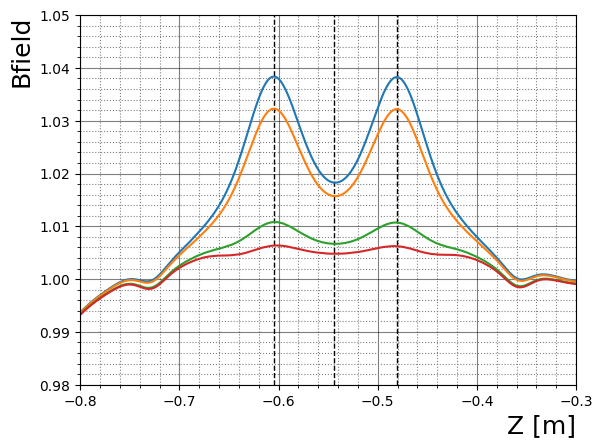

In [8]:
plotter_nicer("Z [m]", "Bfield")
plt.xlim(-0.800, -0.300)
plt.ylim(0.98, 1.05)
plt.axvline(-0.605, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(-0.544, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(-0.481, linestyle = "--", color = "black", linewidth = 1)
plt.plot(Z, Bfield_20mT_pregravity(Z))
plt.plot(Z, Bfield_17mT(Z))
plt.plot(Z, Bfield_5mT(Z))
plt.plot(Z, Bfield_2p5mT(Z))

## Create the 3 segment potentials

In [9]:
def BfieldExtended(function, X, Y, Z, k, p):
    "3d extent of the magnetic field model, assuming harmonic potential"
    r = np.sqrt(X*X + Y*Y)
    return function(Z) * (1 + k*r**p)

## Create Magnetic field and Gradient Grid

In [10]:
zgrid = np.linspace(-0.800, -0.300, 100000)   # half mm of discretization
z0 = zgrid[0]
dz = np.diff(zgrid)[0]

dBfield_20mT_pregravity_dz  = np.array(Gradient_Computation_1d(Bfield_20mT_pregravity, zgrid))
Bfield_20mT_pregravity_grid = np.array(Bfield_20mT_pregravity(zgrid))

dBfield_17mT_dz             = np.array(Gradient_Computation_1d(Bfield_17mT, zgrid))
Bfield_17mT_grid            = np.array(Bfield_17mT(zgrid))

dBfield_5mT_dz              = np.array(Gradient_Computation_1d(Bfield_5mT, zgrid))
Bfield_5mT_grid             = np.array(Bfield_5mT(zgrid))

dBfield_2p5mT_dz            = np.array(Gradient_Computation_1d(Bfield_2p5mT, zgrid))
Bfield_2p5mT_grid           = np.array(Bfield_2p5mT(zgrid))

In [11]:
#print(dBfield_20mT_pregravity_dz)

## Simulation Setting

In [12]:
nAtoms = 1000
Time = 0

## Define variables for visualization

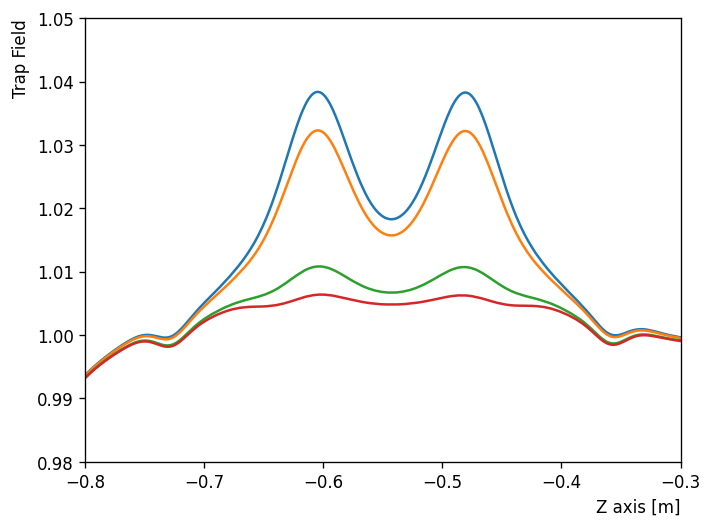

In [13]:
import matplotlib.animation as animation
from matplotlib import rc
from matplotlib import rcParams
from IPython.display import HTML
plt.rcParams['figure.dpi']  = 120  # non 200-300
plt.rcParams['savefig.dpi'] = 120
rc('animation', html='jshtml')   # dice a Matplotlib di rendere l'animazione come HTML/JS

# Imposta il rendering e il limite di embed PRIMA di creare l'animazione
rcParams['animation.html'] = 'jshtml'
rcParams['animation.embed_limit'] = 800.0  # in MB (float)

fig, ax = plt.subplots()

ax.set_xlim(-0.800, -0.300)
ax.set_ylim(0.98, 1.05)
ax.set_xlabel("Z axis [m]", loc = "right")
ax.set_ylabel("Trap Field", loc = "top")

particles_plots = [ax.plot([], [], 'ro', markersize= 2)[0] for _ in range(nAtoms)]  # Palline rosse

# Testo per i contatori
left_count = 0
right_count = 0
asym = None

#text_left   = ax.text(-0.800 + 0.020,  1.04, f"Left: {left_count}", fontsize=7, color='blue')
#text_right  = ax.text(-0.300 - 0.050, 1.04, f"Right: {right_count}", fontsize=7, color='blue')

plt.plot(Z, Bfield_20mT_pregravity(Z))
plt.plot(Z, Bfield_17mT(Z))
plt.plot(Z, Bfield_5mT(Z))
plt.plot(Z, Bfield_2p5mT(Z))

## Simulation Test

In [14]:
# Segment 1,
def segment1(Z,T, ramplength):
    return Bfield_20mT_pregravity(Z) + (Bfield_17mT(Z) - Bfield_20mT_pregravity(Z)) * ( T/ramplength)

# Segment 2,
def segment2(Z,T, ramplength):
    return Bfield_17mT(Z) + (Bfield_5mT(Z) - Bfield_17mT(Z)) * ( T/ramplength)

# Segment 3,
def segment3(Z,T, ramplength):
    return Bfield_5mT(Z) + (Bfield_2p5mT(Z) - Bfield_5mT(Z)) * ( T/ramplength)

In [15]:
# # Initialize the atoms
# Time = 0
# left_count = 0
# right_count = 0

# # linea iniziale (metti un campo qualsiasi, verrà sovrascritto)
# y0 = Bfield_20mT_pregravity(zgrid)  # o quello che vuoi come "inizio"
# line, = ax.plot(zgrid, y0, lw=1.5, color = "black", linestyle = "--")

# def update(frame):
#     global Time, zgrid
#     left_count, right_count = 0, 0

#     if(frame % 100 == 0): print(f"frame {frame}")
#     # Avanza il tempo UNA volta per frame
#     Time += 0.1
#     #print(Time)

#     # ================================================================
#     # IDENTIFICAZIONE DEL SEGMENTO
#     # ================================================================
#     if (Time >= 0) and (Time < Tramp1):
#         # SEGMENTO 1
#         Bfield = lambda z: segment1(z, Time - 0, 10)
#     elif (Time >= Tramp1) and (Time < wait_ramp1):
#         # WAIT 1
#         Bfield = Bfield_17mT
#     elif (Time >= wait_ramp1) and (Time < Tramp2):
#         # SEGMENTO 2
#         Bfield = lambda z: segment2(z, Time - wait_ramp1, 10)
#     elif (Time >= Tramp2) and (Time < wait_ramp2):
#         # WAIT 2
#         Bfield = Bfield_5mT
#     elif (Time >= wait_ramp2) and (Time < Tramp3):
#         # SEGMENTO 3
#         Bfield = lambda z: segment3(z, Time - wait_ramp2, 10)
#     else:
#         # Fuori dai segmenti → lascia il campo finale
#         Bfield = Bfield_5mT


#     # ================================================================
#     # AGGIORNAMENTO DEL CAMPO
#     # ================================================================
#     line.set_data(zgrid, Bfield(zgrid))
    
#     # Ritornare SEMPRE tutti gli artist
#     return line

# ani = animation.FuncAnimation(
#     fig, update,
#     frames=500,
#     interval=16,
#     blit=False
# )


# HTML(ani.to_jshtml())            # <-- questo fa apparire l’animazione in JupyterLab

# SIMULATION
- **Initialize the particles.**
- **loop to update the particles, verlet velocity.**
- **Define Up and down regions.**

In [16]:
from UTILS import Gradient_Computation_1d, Gradient_Computation_3d, InitialCondition_3d

In [17]:
# Initialize the atoms
Time = 0

# Initialize the particles
R_array = []
V_array = []
Time_Annihilation = []
Annihilation      = []
for _ in range(nAtoms):
    #print("Extracting values:")
    Vinit, Rinit = InitialCondition_3d(Bfield_20mT_pregravity, CONSTANTS) # Define initial conditions of the simulation
    # Initial position
    R_array.append(Rinit)
    
    V_array.append(Vinit)             # Initial speed
    Time_Annihilation.append(np.nan)  # Time annihilation
    Annihilation.append(False)        # Annihilation bool array

print(R_array)
dB_buffer = np.empty(3, dtype=np.float64)
R_array = np.array(R_array)
V_array = np.array(V_array)
Time_Annihilation = np.array(Time_Annihilation).flatten()
Annihilation = np.array(Annihilation).flatten()

[array([ 0.        ,  0.        , -0.51430866]), array([ 0.        ,  0.        , -0.54049834]), array([ 0.        ,  0.        , -0.52631675]), array([ 0.        ,  0.        , -0.52186011]), array([ 0.        ,  0.        , -0.54574408]), array([ 0.        ,  0.        , -0.54806374]), array([ 0.        ,  0.        , -0.54617158]), array([ 0.        ,  0.        , -0.57830196]), array([ 0.        ,  0.        , -0.53340131]), array([ 0.        ,  0.        , -0.55803645]), array([ 0.       ,  0.       , -0.5421245]), array([ 0.        ,  0.        , -0.55279621]), array([ 0.        ,  0.        , -0.54229061]), array([ 0.        ,  0.        , -0.50792273]), array([ 0.        ,  0.        , -0.57130818]), array([ 0.        ,  0.        , -0.53543723]), array([ 0.        ,  0.        , -0.53862182]), array([ 0.        ,  0.        , -0.56851596]), array([ 0.       ,  0.       , -0.5678716]), array([ 0.        ,  0.        , -0.52579982]), array([ 0.        ,  0.        , -0.53114028]

In [18]:
# dummy call
# mini chiamata “dummy” per triggerare la compilazione:
step_all_particles.py_func(
    R_array, V_array, 
    0.0, 0, 
    0.0, 10.0,
    z0, dz,
    dBfield_20mT_pregravity_dz, 
    Bfield_20mT_pregravity_grid,
    dBfield_17mT_dz,
    Bfield_17mT_grid,
    Annihilation, Time_Annihilation,
    dB_buffer,
    theta, tau_mixing)

evolve_all_particles.py_func(
    R_array, V_array, Time,
    z0, dz,
    Annihilation, Time_Annihilation,
    dB_buffer,
    theta, tau_mixing,
    dBfield_20mT_pregravity_dz,
    Bfield_20mT_pregravity_grid,
    dBfield_17mT_dz,
    Bfield_17mT_grid,
    dBfield_5mT_dz,
    Bfield_5mT_grid,
    dBfield_2p5mT_dz,
    Bfield_2p5mT_grid,
    0, 0, 
    0, 0, 
    0, 0)

In [19]:
Tramp1     = 11.2
wait_ramp1 = 121.5 + Tramp1

Tramp2     = 11.2 + wait_ramp1
wait_ramp2 = 121.5 + Tramp2

Tramp3     = 11.2 + wait_ramp2
wait_ramp3 = 121.5 + Tramp3

In [20]:
start_time = time.time()
print( f"Tot Frame : {int(wait_ramp3/dt)}")
evolve_all_particles(R_array, V_array, Time,
        z0, dz,
        Annihilation, Time_Annihilation,
        dB_buffer,
        theta, tau_mixing,
        dBfield_20mT_pregravity_dz,
        Bfield_20mT_pregravity_grid,
        dBfield_17mT_dz,
        Bfield_17mT_grid,
        dBfield_5mT_dz,
        Bfield_5mT_grid,
        dBfield_2p5mT_dz,
        Bfield_2p5mT_grid,
        Tramp1, wait_ramp1, 
        Tramp2, wait_ramp2, 
        Tramp3, wait_ramp3)


Tot Frame : 3980999


In [21]:
print(time.time() - start_time)

14.13450312614441


[-0.32496625 -0.54791008 -0.32347954 -0.55702219 -0.54092302 -0.32484148
 -0.55755222 -0.32432489 -0.52239491 -0.49773805 -0.32447609 -0.52094387
 -0.5439805  -0.32386253 -0.32498907 -0.5730927  -0.5569542  -0.32498123
 -0.32428914 -0.53782737 -0.57946594 -0.32413653 -0.32436172 -0.32425786
 -0.53683857 -0.32364812 -0.56709405 -0.3244045  -0.57375641 -0.56660744
 -0.52328125 -0.3247693  -0.56342263 -0.32493141 -0.53732808 -0.32465033
 -0.32384727 -0.32416227 -0.32490229 -0.32449085 -0.54998931 -0.54452087
 -0.56821536 -0.32463829 -0.55565689 -0.32409125 -0.32411632 -0.32456418
 -0.32492871 -0.55068543 -0.57231306 -0.3242026  -0.32429029 -0.3247007
 -0.55559935 -0.32341539 -0.32441579 -0.32485927 -0.5752058  -0.56501573
 -0.32384568 -0.32470331 -0.5768632  -0.56263186 -0.50237151 -0.53209768
 -0.32485016 -0.51331361 -0.53782538 -0.32455881 -0.32357162 -0.3247858
 -0.3247812  -0.5767168  -0.50125473 -0.58340604 -0.32472636 -0.50761255
 -0.32481117 -0.52913718 -0.32495251 -0.32428288 -0.3

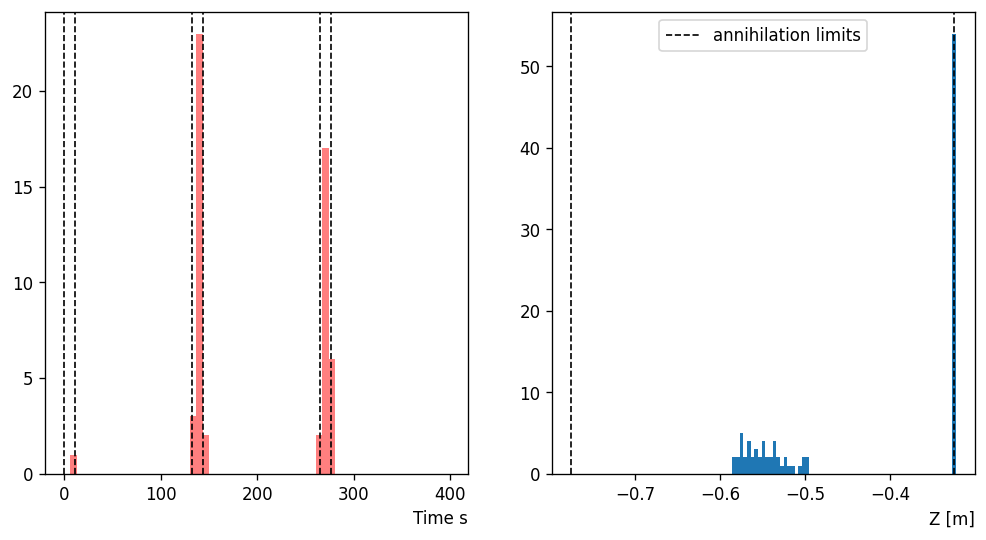

In [22]:
plt.figure(1, figsize = (10, 5))
plt.subplot(1,2,1)
plt.axvline(0, linestyle = '--', color = "black", linewidth = 1)
plt.axvline(Tramp1, linestyle = '--', color = "black", linewidth = 1)
plt.axvline(wait_ramp1, linestyle = '--', color = "black", linewidth = 1)
plt.axvline(Tramp2, linestyle = '--', color = "black", linewidth = 1)
plt.axvline(wait_ramp2, linestyle = '--', color = "black", linewidth = 1)
plt.axvline(Tramp3, linestyle = '--', color = "black", linewidth = 1)
plt.xlabel("Time s", loc = "right")
plt.hist(Time_Annihilation, color = "red", bins = 61, range = (0, wait_ramp3), alpha = 0.5)
plt.subplot(1,2,2)
print(R_array[:,2])
plt.hist(R_array[:,2], bins = 61)
plt.axvline(CONSTANTS.zacceptance_min, linestyle = "--", color = 'black', linewidth = 1)
plt.axvline(CONSTANTS.zacceptance_max, linestyle = "--", color = 'black', linewidth = 1,label = "annihilation limits")
plt.xlabel("Z [m]", loc = "right")
plt.legend(loc = "upper center")
plt.savefig(f"figures/{stringa}_axial_{CONSTANTS.Temperature*1000:.1f}mK_transv_{CONSTANTS.Temperature_transv*1000:.1f}mK_p_{CONSTANTS.harmonic_degree}.png")

In [24]:
# Compute LR
import os
import sys
sys.path.append(os.path.abspath(".."))
from scipy import stats
import pandas as pd
from v1.Utils import ReadTheCsv,ReadTheSpill,append_to_dict

In [25]:
def analysis_function(output):
    file = np.load(output)
    R_array           = file['position']
    Time_Annihilation = file['Time']
    Time_Annihilation = Time_Annihilation[np.isfinite(Time_Annihilation)]
    counts, edges = np.histogram(Time_Annihilation, bins = 50, range = (0,398.1), density = False)
    return Time_Annihilation, counts, edges

def analysis_data(file, Zcuts):
    # read the file
    dataset = ReadTheCsv(file, "-1", Zcuts.zmin, Zcuts.zmax, ZCUTS.CutsType)
    # Three Segment Ramp Down
    start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill(file,"\"MBMF RampDown\"[0]")
    start_mbmf_rampdown1, stop_mbmf_rampdown1 = ReadTheSpill(file,"\"MBMF RampDown\"[1]")
    start_mbmf_rampdown2, stop_mbmf_rampdown2 = ReadTheSpill(file,"\"MBMF RampDown\"[2]")

    # print(f"{start_mbmf_rampdown0[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown0[0] - start_mbmf_rampdown0[0]} ")
    # print(f"{start_mbmf_rampdown1[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown1[0] - start_mbmf_rampdown1[0]} ")
    # print(f"{start_mbmf_rampdown2[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown2[0] - start_mbmf_rampdown2[0]} ")
    mask      = ((dataset[CutsType] == 1) & 
                (dataset["Z"] > ZCUTS.zmin) & 
                (dataset["Z"] < ZCUTS.zmax))
    mask_time = ((dataset["run time"] > start_mbmf_rampdown0[0]) & 
                 (dataset["run time"] < start_mbmf_rampdown0[0] + 398.1))

    Event_Distribution = dataset["run time"][mask & mask_time].to_numpy() - start_mbmf_rampdown0[0]
    X_distribution = dataset["X"][mask & mask_time].to_numpy()
    Y_distribution = dataset["Y"][mask & mask_time].to_numpy()
    Z_distribution = dataset["Z"][mask & mask_time].to_numpy()

    counts, edges = np.histogram(Event_Distribution, bins = 50, range = (0,398.1), density = False)
    
    return Event_Distribution, counts, edges

In [26]:
mirG_center = -415
mirA_center = -671
zmin = mirA_center - 200
zgap_min = mirA_center
zmax = mirG_center + 200
zgap_max = mirG_center
CutsType = "CutsType2"

class Zcuts:
    def __init__(self,a,b, cuts):
        self.mirG_center = a
        self.mirA_center = b
        self.zmin = b - 200
        self.zmax = a + 200
        self.zgap_min = b
        self.zgap_max = a
        self.CutsType = cuts

ZCUTS = Zcuts(-415,-671, CutsType)

In [30]:
list_dataset = ["v1/ag14100/ag14100.vertex.csv",
                "v1/ag14106/ag14106.vertex.csv",
                "v1/ag14268/ag14268.vertex.csv",
                "v1/ag14286/ag14286.vertex.csv",
                "v1/ag14308/ag14308.vertex.csv"]

# Load the data in a dictionary
dict_runs = {}
for dataset in list_dataset:
    Event_Distribution, counts_obs, edges_obs = analysis_data("../" + dataset, ZCUTS)
    append_to_dict(dict_runs, dataset, counts_obs)

# Initialize total LR
LR_total    = 0

# Bin The Simulation
counts_sim, edges_sim = np.histogram(Time_Annihilation[np.isfinite(Time_Annihilation)],
                                     bins = 50, 
                                     range = (0,398.1), 
                                     density = False)

# Compute the sum of LR
for dataset in list_dataset:        
    counts_obs = dict_runs[dataset][0]
    
    counts_sim = counts_sim * counts_obs.sum() / counts_sim.sum()
    
    LR, pvalue_lr = stats.power_divergence(counts_obs, counts_sim, lambda_="log-likelihood")
    
    LR_total += LR
    
    print(f"LR statistic = {LR:.4}/{(len(counts_obs) - 1)}")

    if not np.isfinite(LR_total):
        LR_total = 9999999

print(f"best LR {LR_total}")
print("-"*16)

../v1/ag14100/ag14100.vertex.csv
   [26850.997-26862.199]=  11.202s |          "MBMF RampDown"[0]          |    1074       61       53       29      499      396     1214      852     1931         6 

../v1/ag14100/ag14100.vertex.csv
   [26983.913-26995.115]=  11.202s |          "MBMF RampDown"[1]          |    1148       51       53       31      545      420     1317     1208     2690       116 

../v1/ag14100/ag14100.vertex.csv
   [27116.943-27128.146]=  11.202s |          "MBMF RampDown"[2]          |    1104       56       55       42      545      447     1307     1285     2653       142 

../v1/ag14106/ag14106.vertex.csv
   [23785.519-23796.721]=  11.202s |          "MBMF RampDown"[0]          |    1670       81       83       75     1093      800     2652      958     3535         8 

../v1/ag14106/ag14106.vertex.csv
   [23918.318-23929.520]=  11.202s |          "MBMF RampDown"[1]          |    1150       60       61       41      534      426     1250     1245     2562        

/home/adriano/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:8025: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_obs, f_obs / f_exp)
/home/adriano/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:8025: RuntimeWarning: invalid value encountered in divide
  terms = 2.0 * special.xlogy(f_obs, f_obs / f_exp)


In [31]:
# Save output
np.savez(f"output/{stringa}",
         position = R_array,
         Time     = Time_Annihilation,
         metric   = LR_total)